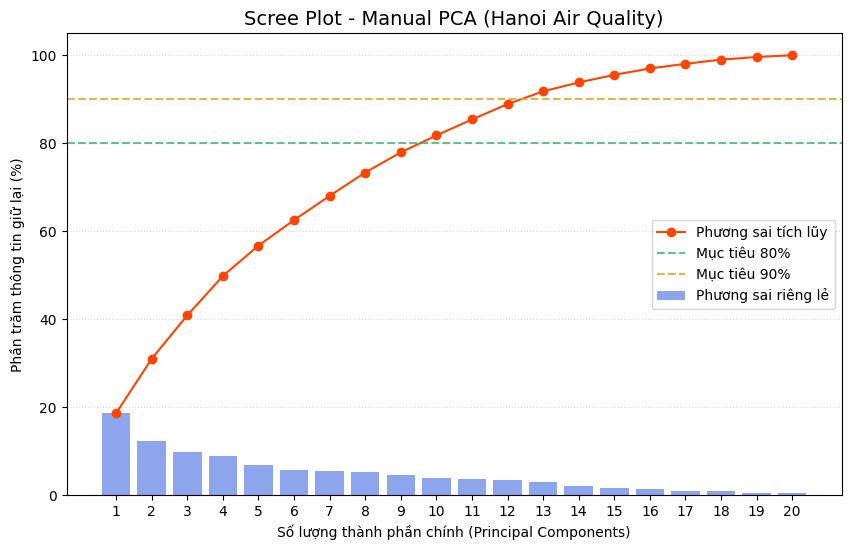

KẾT LUẬN: Để giữ >90% thông tin, cần chọn 13 thành phần chính.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Đọc dữ liệu từ folder clean
try:
    df = pd.read_csv('../clean/hanoi_aqi_cleaned.csv')
except:
    df = pd.read_csv('./clean/hanoi_aqi_cleaned.csv')

# 2. Loại bỏ cột AQI (Target) và lấy các cột số còn lại (13 cột)
X = df.drop(columns=['AQI']) if 'AQI' in df.columns else df.copy()
X = X.select_dtypes(include=[np.number]).dropna()
X_values = X.values

# 3. Chuẩn hóa thủ công (Standardization)
X_mean = np.mean(X_values, axis=0)
X_std = np.std(X_values, axis=0)
X_scaled = (X_values - X_mean) / (X_std + 1e-8)

# 4. Tính ma trận Hiệp phương sai & Trị riêng
cov_matrix = np.cov(X_scaled.T)
eigen_values, eigen_vectors = np.linalg.eig(cov_matrix)

# 5. Sắp xếp và tính % phương sai tích lũy
sorted_index = np.argsort(eigen_values)[::-1]
sorted_eigenvalues = np.real(eigen_values[sorted_index])
exp_var = (sorted_eigenvalues / np.sum(sorted_eigenvalues)) * 100
cum_var = np.cumsum(exp_var)

# 6. Vẽ biểu đồ Scree Plot "Khuỷu tay" chuyên nghiệp
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(exp_var) + 1), exp_var, alpha=0.6, color='royalblue', label='Phương sai riêng lẻ')
plt.plot(range(1, len(cum_var) + 1), cum_var, marker='o', color='orangered', label='Phương sai tích lũy')

# Vẽ đường ngưỡng 80% và 90%
plt.axhline(y=80, color='mediumseagreen', linestyle='--', alpha=0.8, label='Mục tiêu 80%')
plt.axhline(y=90, color='goldenrod', linestyle='--', alpha=0.8, label='Mục tiêu 90%')

# Tự động tìm số lượng PC tại các ngưỡng
pc_80 = np.argmax(cum_var >= 80) + 1
pc_90 = np.argmax(cum_var >= 90) + 1

plt.title('Scree Plot - Manual PCA (Hanoi Air Quality)', fontsize=14)
plt.xlabel('Số lượng thành phần chính (Principal Components)')
plt.ylabel('Phần trăm thông tin giữ lại (%)')
plt.xticks(range(1, len(exp_var) + 1))
plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.legend(loc='center right')
plt.show()

print(f"KẾT LUẬN: Để giữ >90% thông tin, cần chọn {pc_90} thành phần chính.")